# 1. 서론 (Introduction) 🐱

## 1.1 분석 배경 및 목적
본 분석은 신용 위험 데이터를 기반으로 고객의 신용 등급(class)에 영향을 미치는 요인을 파악하는 것을 목적으로 한다.

## 1.2 데이터셋 설명
OpenML의 credit-g 데이터를 사용하였다. 해당 데이터는 고객의 다양한 정보(나이, 신용 금액 등)를 기반으로 신용 등급을 분류하는 데이터이다.

## 1.3 주요 분석 질문
- 어떤 변수들이 신용 등급에 영향을 미치는가?
- 변수 간 관계는 어떻게 나타나는가?

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
data = fetch_openml(name='credit-g', version=1, as_frame=True)

df = data.frame
df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


## 2.1 데이터 명세 확인
데이터의 구조를 확인한다.

In [14]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

## 2.2 결측치 분석
결측치 여부를 확인한다.

In [12]:
df.isnull().sum()

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


## 2.3 기초 통계량 분석
수치형 변수의 기본 통계량을 확인한다.

In [15]:
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [10]:
df = df.drop_duplicates()

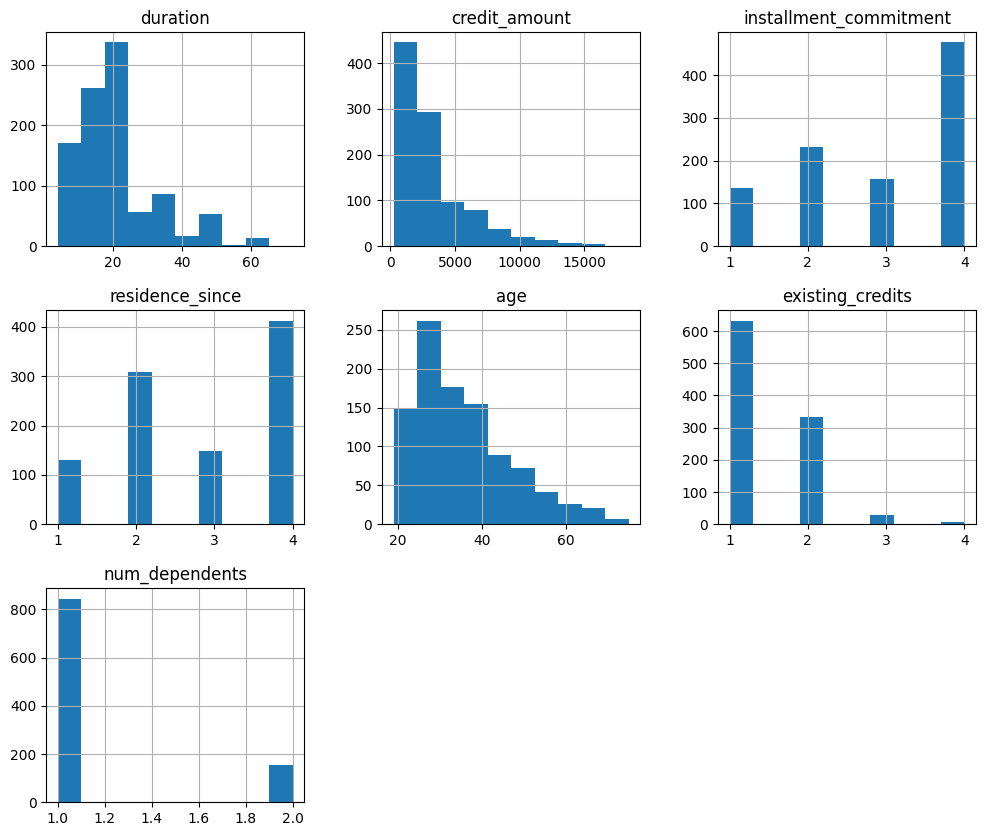

,count
class,
good,700
bad,300


In [3]:
df.hist(figsize=(12,10))
plt.show()

df['class'].value_counts()

## 2.4 데이터 정제:
중복 데이터를 제거한다.

In [16]:
df = df.drop_duplicates()
df.shape

(1000, 21)

## 3.1 수치형 변수 분석
히스토그램을 통해 분포를 확인한다.

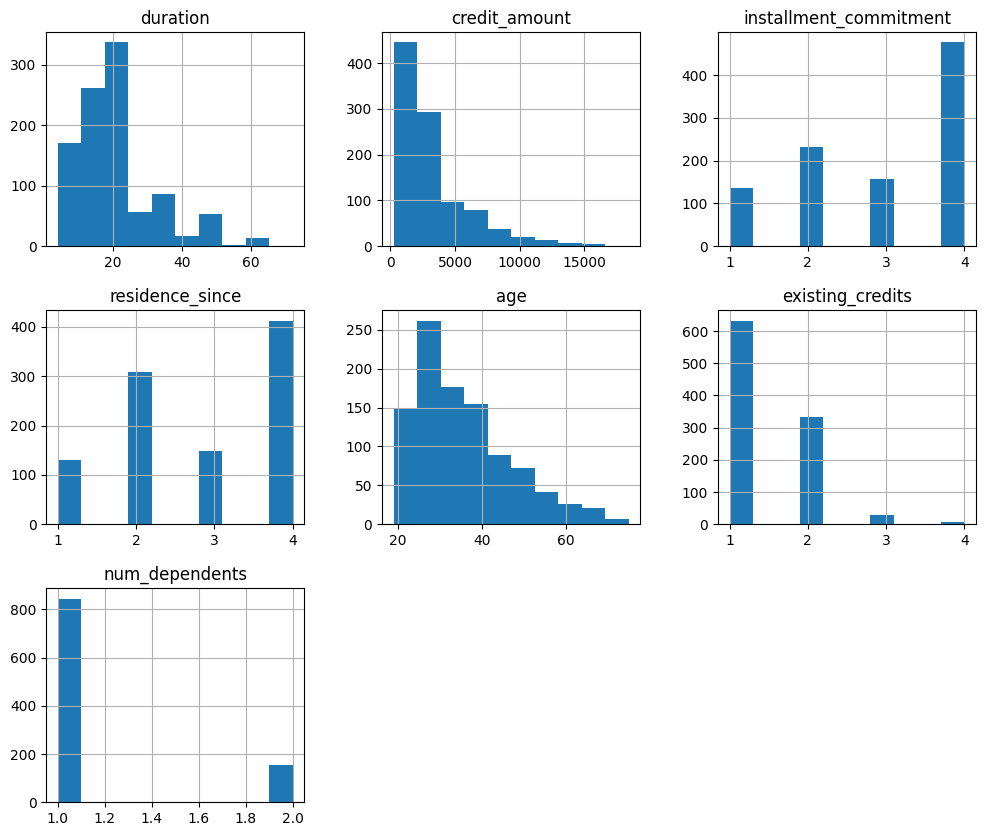

In [17]:
df.hist(figsize=(12,10))
plt.show()

## 3.2 범주형 변수 분석
범주형 변수의 분포를 확인한다.

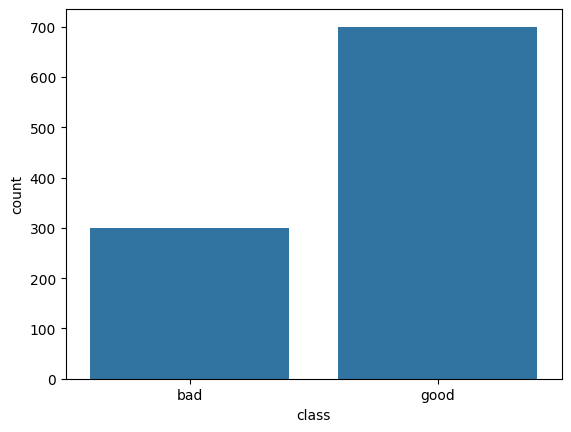

In [18]:
df['class'].value_counts()

sns.countplot(x='class', data=df)
plt.show()

## 4.1 상관관계 분석
히트맵을 통해 변수 간 관계를 확인한다.

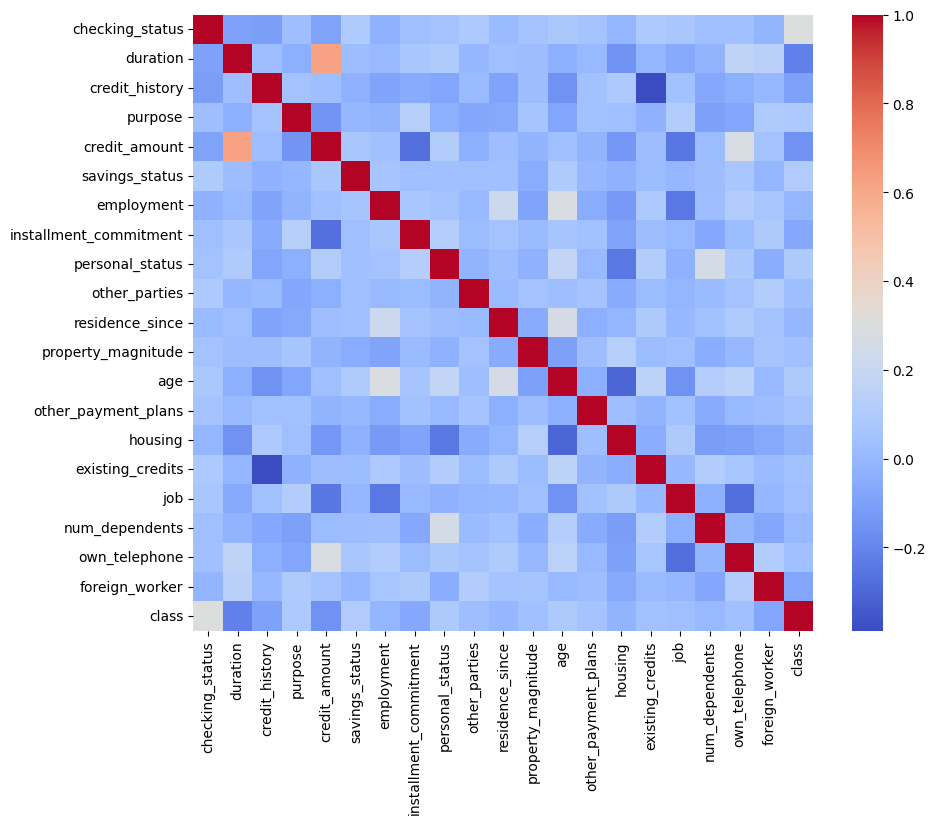

In [20]:
df_encoded = df.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'category' or df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.show()

## 4.2 타겟 변수 기반 분석
박스플롯을 통해 클래스별 차이를 확인한다.

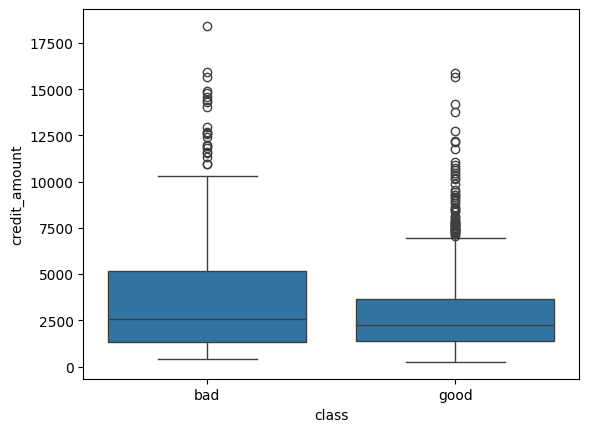

In [22]:
sns.boxplot(x='class', y='credit_amount', data=df)
plt.show()

## 4.3 변수 간 관계 분석
산점도를 통해 변수 간 관계를 확인한다.

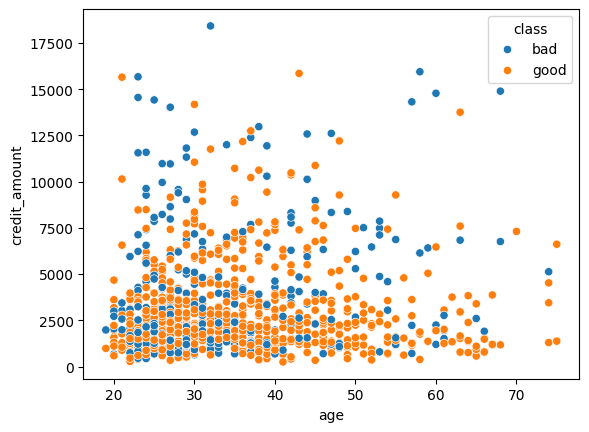

In [23]:
sns.scatterplot(x='age', y='credit_amount', hue='class', data=df)
plt.show()

# 5. 핵심 인사이트

## 5.1 주요 패턴
일부 변수들이 신용 등급과 관련된 패턴을 보인다.

## 5.2 가설 검증
신용 금액 및 나이와 같은 변수들이 일정 수준 영향을 미친다.

## 5.3 예상치 못한 발견
일부 변수는 예상보다 영향력이 낮았다.

# 6. 결론

## 6.1 분석 요약
데이터 구조와 주요 변수 특성을 파악하였다.

## 6.2 비즈니스 제안
신용 평가 모델에 활용 가능하다.

## 6.3 한계점
단순 EDA 분석이며 추가 모델링이 필요하다.